# IDEAL Stage 3: descriptive profiling and temporal comparison

This notebook starts from the saved Stage 2 clustering outputs and builds descriptive analysis tables and figures for the 39 enhanced homes.

## Step 1. Load Stage 2 outputs

Read the clustered daily archetype table and the household-level modal archetype table from the organised output folders.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd()
if ROOT.name == 'script':
    ROOT = ROOT.parent
SCRIPT_DIR = ROOT / 'script'
STAGE2_DIR = SCRIPT_DIR / 'outputs' / 'stage2_clustering'
STAGE3_DIR = SCRIPT_DIR / 'outputs' / 'stage3_descriptive'
STAGE3_DIR.mkdir(parents=True, exist_ok=True)

DAILY_PATH = STAGE2_DIR / 'daily_archetypes_enhanced.csv'
HOUSEHOLD_PATH = STAGE2_DIR / 'household_archetypes_enhanced.csv'

daily_df = pd.read_csv(DAILY_PATH, low_memory=False)
household_df = pd.read_csv(HOUSEHOLD_PATH, low_memory=False)

print(f'daily rows: {len(daily_df)}')
print(f'household rows: {len(household_df)}')
daily_df[['daily_archetype', 'archetype_name', 'homeid', 'date']].head()

daily rows: 9251
household rows: 39


,daily_archetype,archetype_name,homeid,date
0,2,Evening peak,61,2016-10-07
1,0,Morning peak,61,2016-10-08
2,3,Late-afternoon peak,61,2016-10-09
3,1,All-daytime plateau,61,2016-10-10
4,3,Late-afternoon peak,61,2016-10-11


## Step 2. Define helper functions

These helpers keep the profiling logic readable and reusable.

In [2]:
ARCHETYPE_ORDER = [
    'Morning peak',
    'All-daytime plateau',
    'Evening peak',
    'Late-afternoon peak',
    'Early-morning peak',
]

def mode_or_missing(series: pd.Series):
    s = series.dropna()
    non_missing = s[s != 'Missing']
    if not non_missing.empty:
        non_missing_mode = non_missing.mode()
        if not non_missing_mode.empty:
            return non_missing_mode.iat[0]
    mode = s.mode()
    return mode.iat[0] if not mode.empty else 'Missing'

def ordered(df: pd.DataFrame, name_col: str = 'archetype_name') -> pd.DataFrame:
    df = df.copy()
    df[name_col] = pd.Categorical(df[name_col], categories=ARCHETYPE_ORDER, ordered=True)
    return df.sort_values(name_col).reset_index(drop=True)

## Step 3. Build the day-level archetype profile

Summarise how common each daily archetype is, when it peaks, how weekend-heavy it is, and how much energy it uses.

In [3]:
day_profile = (
    daily_df.groupby(['daily_archetype', 'archetype_name']).agg(
        n_days=('homeid', 'size'),
        n_homes=('homeid', 'nunique'),
        mean_daily_total_kwh=('daily_total_kwh', 'mean'),
        median_daily_total_kwh=('daily_total_kwh', 'median'),
        mean_peak_hour=('day_peak_hour', 'mean'),
        weekend_share=('is_weekend', 'mean'),
        mean_daytime_fraction=('daytime_fraction', 'mean'),
    )
    .reset_index()
)
day_profile['day_share'] = day_profile['n_days'] / len(daily_df)
day_profile = ordered(day_profile)
day_profile

,daily_archetype,archetype_name,n_days,n_homes,mean_daily_total_kwh,median_daily_total_kwh,mean_peak_hour,weekend_share,mean_daytime_fraction,day_share
0,0,Morning peak,1680,39,8.366644,7.324982,10.375000,0.395238,0.699959,0.181602
1,1,All-daytime plateau,1833,39,11.745623,10.282028,14.274959,0.429896,0.744595,0.198141
2,2,Evening peak,2863,39,7.995803,6.903167,18.352078,0.228082,0.675214,0.309480
3,3,Late-afternoon peak,1638,39,8.917948,8.017824,15.841270,0.288767,0.718217,0.177062
4,4,Early-morning peak,1237,39,8.051673,7.774401,7.928860,0.118836,0.512739,0.133715


## Step 4. Build the temporal profile

Compare weekday vs weekend composition and seasonal mix within each archetype.

In [4]:
weekend_mix = (
    daily_df.assign(day_count=1)
    .pivot_table(index=['daily_archetype', 'archetype_name'], columns='is_weekend', values='day_count', aggfunc='sum', fill_value=0)
    .rename(columns={False: 'weekday_days', True: 'weekend_days'})
    .reset_index()
)
weekend_mix['weekday_share_within_archetype'] = weekend_mix['weekday_days'] / (weekend_mix['weekday_days'] + weekend_mix['weekend_days'])
weekend_mix['weekend_share_within_archetype'] = weekend_mix['weekend_days'] / (weekend_mix['weekday_days'] + weekend_mix['weekend_days'])

season_mix = (
    daily_df.assign(day_count=1)
    .pivot_table(index=['daily_archetype', 'archetype_name'], columns='season', values='day_count', aggfunc='sum', fill_value=0)
    .rename(columns=lambda c: f'{str(c).lower()}_days')
    .reset_index()
)

total_by_arch = daily_df.groupby(['daily_archetype', 'archetype_name']).size().rename('n_days').reset_index()
temporal_profile = weekend_mix.merge(season_mix, on=['daily_archetype', 'archetype_name'], how='left').merge(total_by_arch, on=['daily_archetype', 'archetype_name'], how='left')
for season in ['autumn', 'spring', 'summer', 'winter']:
    days_col = f'{season}_days'
    temporal_profile[f'{season}_share_within_archetype'] = temporal_profile[days_col] / temporal_profile['n_days']

temporal_profile = ordered(temporal_profile)
temporal_profile

,daily_archetype,archetype_name,weekday_days,weekend_days,weekday_share_within_archetype,weekend_share_within_archetype,autumn_days,spring_days,summer_days,winter_days,n_days,autumn_share_within_archetype,spring_share_within_archetype,summer_share_within_archetype,winter_share_within_archetype
0,0,Morning peak,1016,664,0.604762,0.395238,315,555,363,447,1680,0.187500,0.330357,0.216071,0.266071
1,1,All-daytime plateau,1045,788,0.570104,0.429896,368,528,272,665,1833,0.200764,0.288052,0.148391,0.362793
2,2,Evening peak,2210,653,0.771918,0.228082,531,953,518,861,2863,0.185470,0.332868,0.180929,0.300733
3,3,Late-afternoon peak,1165,473,0.711233,0.288767,356,573,330,379,1638,0.217338,0.349817,0.201465,0.231380
4,4,Early-morning peak,1090,147,0.881164,0.118836,241,391,314,291,1237,0.194826,0.316087,0.253840,0.235247


## Step 5. Build the household profile

Describe the homes whose modal archetype falls into each cluster.

In [5]:
household_profile = (
    household_df.groupby(['household_modal_archetype', 'household_modal_archetype_name']).agg(
        modal_homes=('homeid', 'size'),
        mean_residents=('residents', 'mean'),
        median_residents=('residents', 'median'),
        mean_major_app_total=('major_app_total', 'mean'),
        mean_other_app_total=('other_app_total', 'mean'),
        modal_hometype=('hometype', mode_or_missing),
        modal_income_band=('income_band', mode_or_missing),
        modal_workingstatus=('workingstatus', mode_or_missing),
    )
    .reset_index()
    .rename(columns={'household_modal_archetype': 'daily_archetype', 'household_modal_archetype_name': 'archetype_name'})
)
household_profile = ordered(household_profile)
household_profile

,daily_archetype,archetype_name,modal_homes,mean_residents,median_residents,mean_major_app_total,mean_other_app_total,modal_hometype,modal_income_band,modal_workingstatus
0,0,Morning peak,8,1.875000,2.0,17.125000,14.500000,flat,"£43,200 to £48,599",Paid work
1,1,All-daytime plateau,11,2.818182,3.0,21.181818,16.909091,flat,"£43,200 to £48,599",Paid work
2,2,Evening peak,15,1.866667,2.0,20.133333,15.200000,flat,"£23,400 to £26,999",Paid work
3,3,Late-afternoon peak,3,2.666667,2.0,20.000000,17.333333,house_or_bungalow,"£48,600 to £53,999",Paid work
4,4,Early-morning peak,2,1.000000,1.0,18.500000,11.500000,flat,"£54,000 to £65,999",Paid work


## Step 6. Build the household stability table

Measure how mixed or stable each home is across the five archetypes.

In [6]:
home_mix = (
    daily_df.assign(day_count=1)
    .pivot_table(index='homeid', columns='archetype_name', values='day_count', aggfunc='sum', fill_value=0)
    .reset_index()
)
archetype_cols = [c for c in home_mix.columns if c != 'homeid']
home_mix['clustered_days'] = home_mix[archetype_cols].sum(axis=1)
home_mix['modal_days'] = home_mix[archetype_cols].max(axis=1)
home_mix['modal_day_share'] = home_mix['modal_days'] / home_mix['clustered_days']
home_mix['n_observed_archetypes'] = (home_mix[archetype_cols] > 0).sum(axis=1)

stability_df = home_mix.merge(
    household_df[['homeid', 'household_modal_archetype', 'household_modal_archetype_name', 'residents', 'major_app_total', 'other_app_total', 'income_band', 'hometype']],
    on='homeid',
    how='left',
)

stability_summary_df = pd.concat([
    pd.DataFrame([{
        'scope': 'overall',
        'households': len(stability_df),
        'mean_modal_day_share': stability_df['modal_day_share'].mean(),
        'median_modal_day_share': stability_df['modal_day_share'].median(),
        'min_modal_day_share': stability_df['modal_day_share'].min(),
        'max_modal_day_share': stability_df['modal_day_share'].max(),
        'mean_n_observed_archetypes': stability_df['n_observed_archetypes'].mean(),
        'homes_with_all_5_archetypes': int((stability_df['n_observed_archetypes'] == 5).sum()),
    }]),
    stability_df.groupby(['household_modal_archetype', 'household_modal_archetype_name']).agg(
        households=('homeid', 'size'),
        mean_modal_day_share=('modal_day_share', 'mean'),
        median_modal_day_share=('modal_day_share', 'median'),
        min_modal_day_share=('modal_day_share', 'min'),
        max_modal_day_share=('modal_day_share', 'max'),
        mean_n_observed_archetypes=('n_observed_archetypes', 'mean'),
    ).reset_index().rename(columns={'household_modal_archetype': 'daily_archetype', 'household_modal_archetype_name': 'scope'}),
], ignore_index=True, sort=False)

stability_df.sort_values(['household_modal_archetype', 'homeid']).head(10)

,homeid,All-daytime plateau,Early-morning peak,Evening peak,Late-afternoon peak,Morning peak,clustered_days,modal_days,modal_day_share,n_observed_archetypes,household_modal_archetype,household_modal_archetype_name,residents,major_app_total,other_app_total,income_band,hometype
4,73,60,17,87,37,144,345,144,0.417391,5,0,Morning peak,3,13,7.0,Missing,flat
13,145,7,75,34,28,135,279,135,0.483871,5,0,Morning peak,2,16,13.0,"£43,200 to £48,599",flat
15,162,34,44,51,32,112,273,112,0.410256,5,0,Morning peak,2,17,20.0,"£54,000 to £65,999",flat
18,171,8,15,12,20,39,94,39,0.414894,5,0,Morning peak,0,19,11.0,"£13,500 to £16,199",flat
20,208,26,10,24,26,145,231,145,0.627706,5,0,Morning peak,2,16,19.0,"£43,200 to £48,599",flat
28,249,16,42,36,28,60,182,60,0.329670,5,0,Morning peak,2,15,13.0,Missing,flat
34,266,11,32,29,15,46,133,46,0.345865,5,0,Morning peak,2,22,21.0,"£66,000 to £77,999",house_or_bungalow
37,311,9,22,14,7,38,90,38,0.422222,5,0,Morning peak,2,19,12.0,"£16,200 to £19,799",flat
10,136,122,18,115,17,25,297,122,0.410774,5,1,All-daytime plateau,1,18,21.0,"£43,200 to £48,599",flat
11,139,75,10,47,12,59,203,75,0.369458,5,1,All-daytime plateau,3,18,11.0,"£37,800 to £43,199",flat


## Step 7. Plot archetype prevalence

Create a simple bar chart showing how common each daily archetype is across all clustered days.

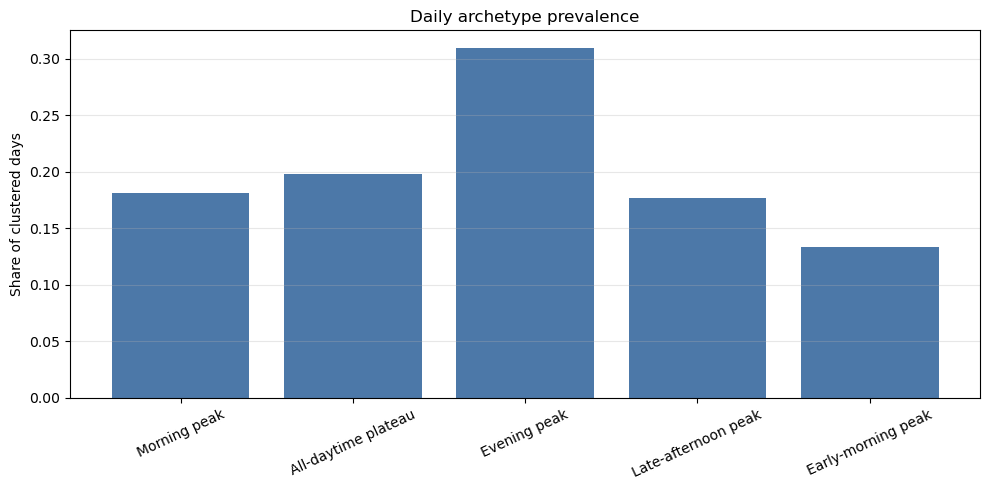

In [7]:
fig_day, ax_day = plt.subplots(figsize=(10, 5))
ax_day.bar(day_profile['archetype_name'], day_profile['day_share'], color='#4C78A8')
ax_day.set_ylabel('Share of clustered days')
ax_day.set_title('Daily archetype prevalence')
ax_day.tick_params(axis='x', rotation=25)
ax_day.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Step 8. Plot temporal comparison

Visualise weekday/weekend composition and seasonal mix within each archetype.

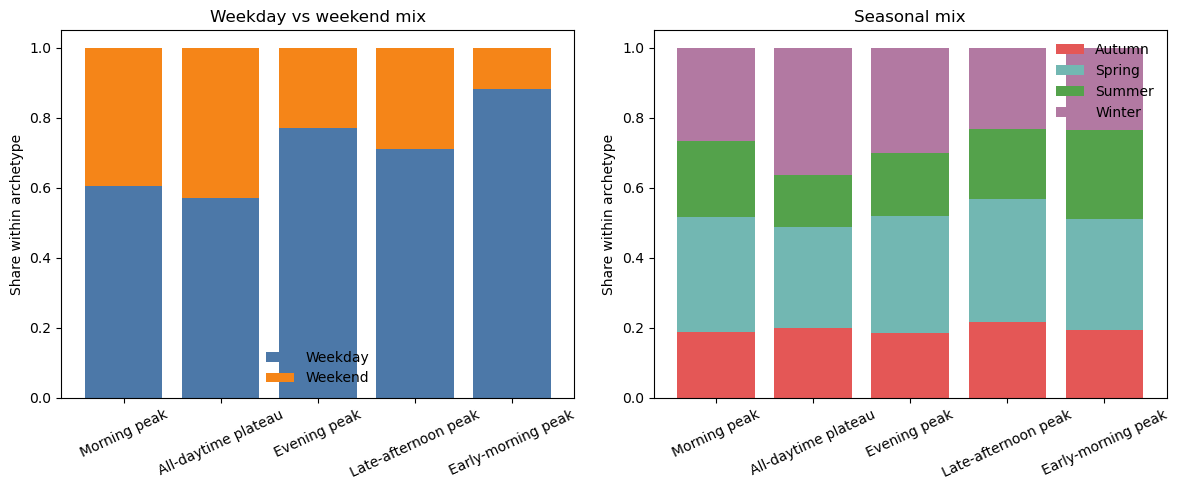

In [8]:
fig_temporal, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(temporal_profile['archetype_name'], temporal_profile['weekday_share_within_archetype'], label='Weekday', color='#4C78A8')
axes[0].bar(temporal_profile['archetype_name'], temporal_profile['weekend_share_within_archetype'], bottom=temporal_profile['weekday_share_within_archetype'], label='Weekend', color='#F58518')
axes[0].set_title('Weekday vs weekend mix')
axes[0].tick_params(axis='x', rotation=25)
axes[0].set_ylabel('Share within archetype')
axes[0].legend(frameon=False)

season_cols = ['autumn_share_within_archetype', 'spring_share_within_archetype', 'summer_share_within_archetype', 'winter_share_within_archetype']
season_labels = ['Autumn', 'Spring', 'Summer', 'Winter']
season_colors = ['#E45756', '#72B7B2', '#54A24B', '#B279A2']
bottom = pd.Series(0.0, index=temporal_profile.index)
for col, label, color in zip(season_cols, season_labels, season_colors):
    axes[1].bar(temporal_profile['archetype_name'], temporal_profile[col], bottom=bottom, label=label, color=color)
    bottom = bottom + temporal_profile[col]
axes[1].set_title('Seasonal mix')
axes[1].tick_params(axis='x', rotation=25)
axes[1].set_ylabel('Share within archetype')
axes[1].legend(frameon=False)

plt.tight_layout()
plt.show()

## Step 9. Plot household profiling

Compare average household size and appliance stock across modal household archetypes.

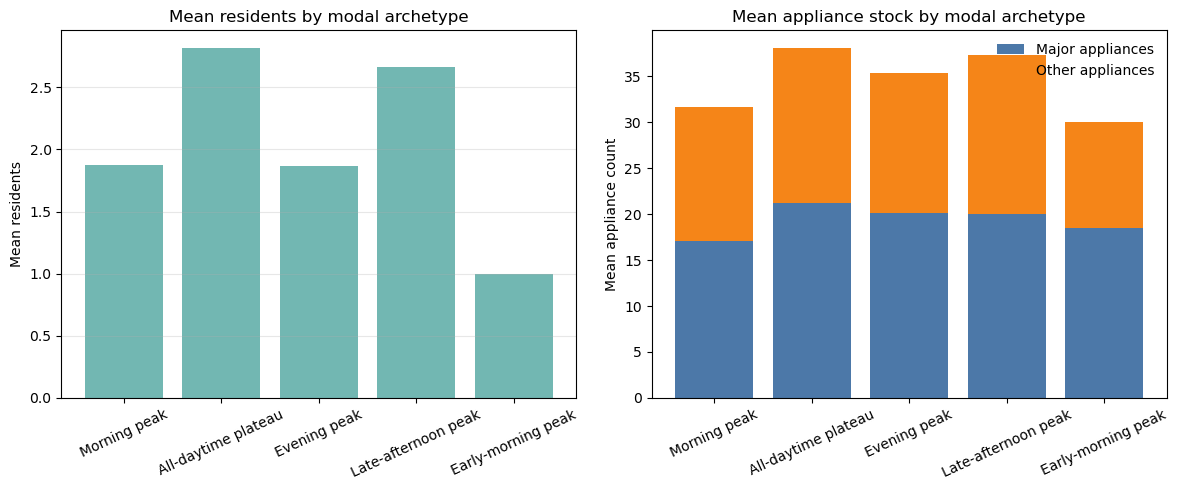

In [9]:
fig_household, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(household_profile['archetype_name'], household_profile['mean_residents'], color='#72B7B2')
axes[0].set_title('Mean residents by modal archetype')
axes[0].tick_params(axis='x', rotation=25)
axes[0].set_ylabel('Mean residents')
axes[0].grid(axis='y', alpha=0.3)

x = range(len(household_profile))
axes[1].bar(x, household_profile['mean_major_app_total'], label='Major appliances', color='#4C78A8')
axes[1].bar(x, household_profile['mean_other_app_total'], bottom=household_profile['mean_major_app_total'], label='Other appliances', color='#F58518')
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(household_profile['archetype_name'], rotation=25)
axes[1].set_title('Mean appliance stock by modal archetype')
axes[1].set_ylabel('Mean appliance count')
axes[1].legend(frameon=False)

plt.tight_layout()
plt.show()

## Step 10. Plot household stability

Visualise modal archetype purity against household size and expose how mixed the household-level labels are.

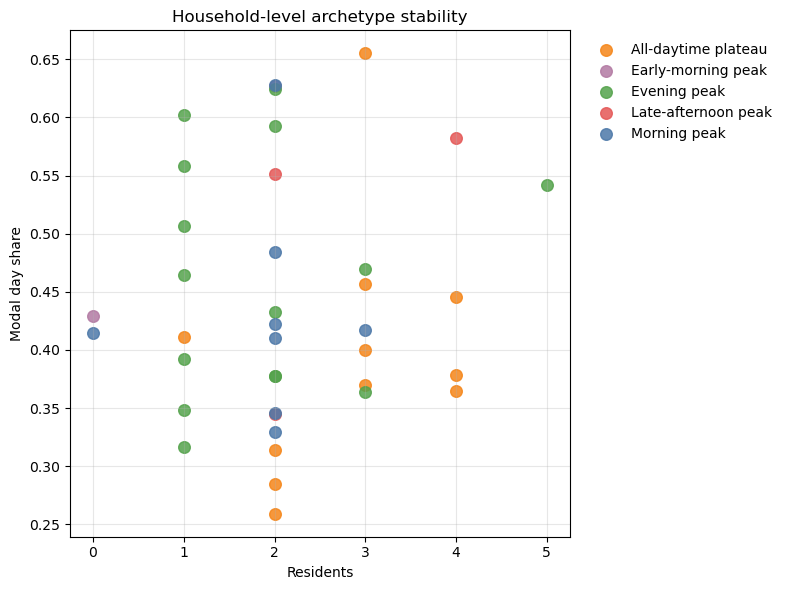

,scope,households,mean_modal_day_share,median_modal_day_share,min_modal_day_share,max_modal_day_share,mean_n_observed_archetypes,homes_with_all_5_archetypes,daily_archetype
0,overall,39,0.443515,0.417391,0.259124,0.655172,5.0,39.0,NaN
1,Morning peak,8,0.431484,0.416142,0.329670,0.627706,5.0,NaN,0.0
2,All-daytime plateau,11,0.394508,0.378698,0.259124,0.655172,5.0,NaN,1.0
3,Evening peak,15,0.464716,0.464883,0.316294,0.624549,5.0,NaN,2.0
4,Late-afternoon peak,3,0.492844,0.551351,0.344828,0.582353,5.0,NaN,3.0
5,Early-morning peak,2,0.528172,0.528172,0.429412,0.626932,5.0,NaN,4.0


In [10]:
fig_stability, ax_stability = plt.subplots(figsize=(8, 6))
color_map = {
    'Morning peak': '#4C78A8',
    'All-daytime plateau': '#F58518',
    'Evening peak': '#54A24B',
    'Late-afternoon peak': '#E45756',
    'Early-morning peak': '#B279A2',
}
for archetype_name, group in stability_df.groupby('household_modal_archetype_name'):
    ax_stability.scatter(group['residents'], group['modal_day_share'], s=70, alpha=0.85, label=archetype_name, color=color_map.get(archetype_name, '#666666'))
ax_stability.set_title('Household-level archetype stability')
ax_stability.set_xlabel('Residents')
ax_stability.set_ylabel('Modal day share')
ax_stability.grid(alpha=0.3)
ax_stability.legend(frameon=False, bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

stability_summary_df

## Step 11. Save Stage 3 outputs

Save the descriptive tables and figures so they can be reused in the report and PPT without rerunning the notebook.

In [11]:
DAY_PROFILE_OUT = SCRIPT_DIR / 'outputs' / 'stage3_descriptive' / 'archetype_day_profile_enhanced.csv'
HOUSEHOLD_PROFILE_OUT = SCRIPT_DIR / 'outputs' / 'stage3_descriptive' / 'archetype_household_profile_enhanced.csv'
TEMPORAL_PROFILE_OUT = SCRIPT_DIR / 'outputs' / 'stage3_descriptive' / 'archetype_temporal_profile_enhanced.csv'
STABILITY_OUT = SCRIPT_DIR / 'outputs' / 'stage3_descriptive' / 'household_archetype_stability_enhanced.csv'
STABILITY_SUMMARY_OUT = SCRIPT_DIR / 'outputs' / 'stage3_descriptive' / 'household_archetype_stability_summary_enhanced.csv'

DAY_SHARE_PLOT = SCRIPT_DIR / 'outputs' / 'stage3_descriptive' / 'archetype_day_share_enhanced.png'
TEMPORAL_PLOT = SCRIPT_DIR / 'outputs' / 'stage3_descriptive' / 'archetype_temporal_mix_enhanced.png'
HOUSEHOLD_PLOT = SCRIPT_DIR / 'outputs' / 'stage3_descriptive' / 'archetype_household_profile_enhanced.png'
STABILITY_PLOT = SCRIPT_DIR / 'outputs' / 'stage3_descriptive' / 'household_archetype_stability_scatter_enhanced.png'

day_profile.to_csv(DAY_PROFILE_OUT, index=False)
temporal_profile.to_csv(TEMPORAL_PROFILE_OUT, index=False)
household_profile.to_csv(HOUSEHOLD_PROFILE_OUT, index=False)
stability_df.to_csv(STABILITY_OUT, index=False)
stability_summary_df.to_csv(STABILITY_SUMMARY_OUT, index=False)

fig_day.savefig(DAY_SHARE_PLOT, dpi=200, bbox_inches='tight')
fig_temporal.savefig(TEMPORAL_PLOT, dpi=200, bbox_inches='tight')
fig_household.savefig(HOUSEHOLD_PLOT, dpi=200, bbox_inches='tight')
fig_stability.savefig(STABILITY_PLOT, dpi=200, bbox_inches='tight')

print(f'Saved day profile to: {DAY_PROFILE_OUT}')
print(f'Saved temporal profile to: {TEMPORAL_PROFILE_OUT}')
print(f'Saved household profile to: {HOUSEHOLD_PROFILE_OUT}')
print(f'Saved household stability to: {STABILITY_OUT}')
print(f'Saved household stability summary to: {STABILITY_SUMMARY_OUT}')
print(f'Saved prevalence plot to: {DAY_SHARE_PLOT}')
print(f'Saved temporal plot to: {TEMPORAL_PLOT}')
print(f'Saved household plot to: {HOUSEHOLD_PLOT}')
print(f'Saved stability scatter to: {STABILITY_PLOT}')

Saved day profile to: /Users/hlbao/Desktop/benv0145/IDEAL/script/outputs/stage3_descriptive/archetype_day_profile_enhanced.csv
Saved temporal profile to: /Users/hlbao/Desktop/benv0145/IDEAL/script/outputs/stage3_descriptive/archetype_temporal_profile_enhanced.csv
Saved household profile to: /Users/hlbao/Desktop/benv0145/IDEAL/script/outputs/stage3_descriptive/archetype_household_profile_enhanced.csv
Saved household stability to: /Users/hlbao/Desktop/benv0145/IDEAL/script/outputs/stage3_descriptive/household_archetype_stability_enhanced.csv
Saved household stability summary to: /Users/hlbao/Desktop/benv0145/IDEAL/script/outputs/stage3_descriptive/household_archetype_stability_summary_enhanced.csv
Saved prevalence plot to: /Users/hlbao/Desktop/benv0145/IDEAL/script/outputs/stage3_descriptive/archetype_day_share_enhanced.png
Saved temporal plot to: /Users/hlbao/Desktop/benv0145/IDEAL/script/outputs/stage3_descriptive/archetype_temporal_mix_enhanced.png
Saved household plot to: /Users/hlba